# Multi-Armed-Bandit with beta-bernoulli mechanics

### Model Definition

In [1]:
# using Pkg #UNCOMMENT IF PACKAGES NOT INSTALLED -> ALSO ADD [add IJulia] IF YOU WANT TO USE JUPYTERS BOOK
# Pkg.add("Gen") 
# Pkg.add("Plots")
# Pkg.add("Random")
# Pkg.add("Distributions")
using Gen, Plots, Random, Distributions, LinearAlgebra

# Model Definition for MAB
@gen function multi_armed_bandit_model(
    success_prior::Vector{Float64},
    fail_prior::Vector{Float64},
    n_pulls_per_arm::Vector{Int}
)
    n_arms = length(success_prior)
    theta = [@trace(Gen.beta(success_prior[i], fail_prior[i]), (:theta, i)) for i in 1:n_arms] # Calculate theta for arm
    
    for i in 1:n_arms
        @trace(binom(n_pulls_per_arm[i], theta[i]), (:obs, i)) # Observation for arm i and theta i
    end
    
    return theta
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Vector{Float64}, Vector{Float64}, Vector{Int64}], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing], Main.var"##multi_armed_bandit_model#230", Bool[0, 0, 0], false)

### Inference Techniques from Gen

In [2]:
# IMPORTANCE SAMPLING
function is_inference(model, args, observations, num_samples)
    (traces, log_weights, _) = Gen.importance_sampling(
        model,
        args,
        observations,
        num_samples
    )
    weights = exp.(log_weights)
    return traces, weights
end

# # Metropolis-Hastings
# function mh_inference(model, args, observations, num_samples)
#     init_trace = Gen.generate(model, args, observations)
#     chain = []
#     for _ in 1:num_samples
#         for i in 1:length(prior_success)
#             (new_trace, _) = Gen.mh(init_trace, Gen.select((:theta, i)))
#             init_trace = new_trace
#         end
#         push!(chain, init_trace)
#     end
#     return chain, ones(num_samples)
# end

# # HMC
# function hmc_inference(model, args, observations, num_samples)
#     init_trace = Gen.generate(model, args, observations)
#     chain = []
#     for _ in 1:num_samples
#         (new_trace, _) = Gen.hmc(init_trace, Gen.select(:theta), epsilon=0.05, L=10)
#         push!(chain, new_trace)
#         init_trace = new_trace
#     end
#     return chain, ones(num_samples)
# end

is_inference (generic function with 1 method)

### Custom Inference Technique


In [3]:
# Conjugate Gibbs Sampler (Sample from conjugate posterior)
function conjugate_gibbs_inference(
    prior_success::Vector{Float64},
    prior_fail::Vector{Float64},
    n_pulls_per_arm::Vector{Int},
    observations::Gen.ChoiceMap,
    num_samples::Int
)
    n_arms = length(prior_success)
    
    # Extract observed successes from choice map
    successes = [observations[(:obs, i)] for i in 1:n_arms]
    
    # Calculate posterior parameters
    post_alpha = prior_success .+ successes
    post_beta = prior_fail .+ n_pulls_per_arm .- successes
    
    # Generate samples directly from posterior
    traces = Vector{Dict{Tuple{Symbol,Int},Float64}}()
    for _ in 1:num_samples
        theta = Dict{Tuple{Symbol,Int},Float64}()
        for i in 1:n_arms
            theta[(:theta, i)] = rand(Beta(post_alpha[i], post_beta[i]))
        end
        push!(traces, theta)
    end
    
    return traces, ones(num_samples)
end

conjugate_gibbs_inference (generic function with 1 method)

### Comparison function

In [4]:
function compare_convergence(sample_sizes,
                             prior_success,
                             prior_fail,
                             n_pulls_per_arm,
                             observations)
    # Calculate analytical truth once
    n_arms = length(prior_success)
    successes = [observations[(:obs, i)] for i in 1:n_arms]
    true_post_alpha = prior_success .+ successes
    true_post_beta = prior_fail .+ n_pulls_per_arm .- successes
    true_means = true_post_alpha ./ (true_post_alpha .+ true_post_beta)
    
    results = Dict{Int, NamedTuple}()
    
    for n in sample_sizes
        # Importance Sampling
        is_traces, is_weights = is_inference(
            multi_armed_bandit_model,
            (prior_success, prior_fail, n_pulls_per_arm),
            observations,
            n
        )
        is_means = [sum([tr[(:theta, i)] * w for (tr, w) in zip(is_traces, is_weights)])/sum(is_weights) 
                   for i in 1:n_arms]
        
        # Conjugate Gibbs
        gibbs_traces, _ = conjugate_gibbs_inference(
            prior_success,
            prior_fail,
            n_pulls_per_arm,
            observations,
            n
        )
        gibbs_means = [mean([tr[(:theta, i)] for tr in gibbs_traces]) for i in 1:n_arms]
        
        # Calculate errors
        results[n] = (
            is_error = norm(is_means - true_means),
            gibbs_error = norm(gibbs_means - true_means)
        )
    end
    
    return results
end

compare_convergence (generic function with 1 method)

### Inference on model

In [5]:
#Initialize all observations & parameters
n_pulls_per_arm = [10, 10]  # Each arm pulled 10 times
prior_success = [1.0, 1.0]  # alpha prior for both arms
prior_fail = [1.0, 1.0] # beta prior for both arms
n_arms = length(n_pulls_per_arm)
model_args = (prior_success, prior_fail, n_pulls_per_arm)
sample_sizes = [10, 100, 1000, 10000, 100000] # For comparison function

# Observed data: 1 success out of 10 for arm 1, 3 out of 10 for arm 2
observations = choicemap()
observations[(:obs, 1)] = 1  # Arm 1 successes
observations[(:obs, 2)] = 3  # Arm 2 successes

3

### Test runs

In [6]:
# Run importance sampling
traces, weights = is_inference(
    multi_armed_bandit_model,
    model_args,
    observations,
    10000
)
posterior_means_is = [
    sum([tr[(:theta, i)] * w for (tr, w) in zip(traces, weights)]) / sum(weights)
    for i in 1:n_arms
]
println("Importance Sampling Posterior means:")
for (i, mean) in enumerate(posterior_means_is)
    println("Arm $i: $(round(mean, digits=3))")
end

# Run conjugate Gibbs
gibbs_traces, gibbs_weights = conjugate_gibbs_inference(
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations,
    10000
)
posterior_means_gibbs = [
    sum([tr[(:theta, i)] * w for (tr, w) in zip(gibbs_traces, gibbs_weights)]) / sum(gibbs_weights)
    for i in 1:n_arms
]
println("Conjugate Gibbs Posterior means:")
for (i, mean) in enumerate(posterior_means_gibbs)
    println("Arm $i: $(round(mean, digits=3))")
end

Importance Sampling Posterior means:
Arm 1: 0.166
Arm 2: 0.327
Conjugate Gibbs Posterior means:
Arm 1: 0.168
Arm 2: 0.333


### Comparison of inference techniques

Convergence Comparison:
Sample Size: 10
  IS Error: 0.06446
  Gibbs Error: 0.0705

Sample Size: 100
  IS Error: 0.01479
  Gibbs Error: 0.04549

Sample Size: 1000
  IS Error: 0.01559
  Gibbs Error: 0.00523

Sample Size: 10000
  IS Error: 0.00294
  Gibbs Error: 0.00234

Sample Size: 100000
  IS Error: 0.00071
  Gibbs Error: 0.00075



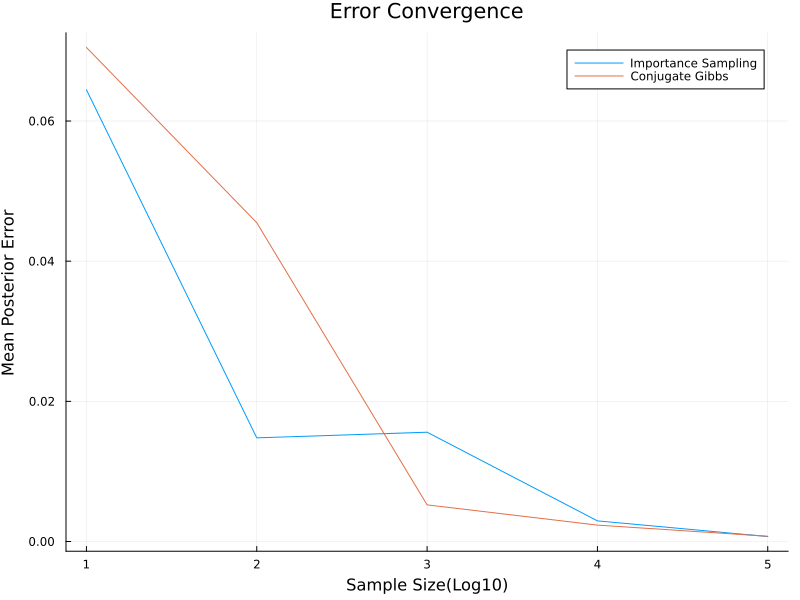

In [7]:
# Parameters passed through comparison function
results = compare_convergence(
    sample_sizes,  # Sample sizes to test
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations  # From choicemap
)

# Print results
println("Convergence Comparison:")
for (n, errs) in sort(collect(results))
    println("""
    Sample Size: $n
      IS Error: $(round(errs.is_error, digits=5))
      Gibbs Error: $(round(errs.gibbs_error, digits=5))
    """)
end

# Error convergence plot
p1 = plot([results[n].is_error for n in sample_sizes], 
        label="Importance Sampling", 
        y=:log10,
        xlabel="Sample Size(Log10)", 
        ylabel="Mean Posterior Error",
        title="Error Convergence")
plot!([results[n].gibbs_error for n in sample_sizes], 
     label="Conjugate Gibbs")


plot(p1, size=(800, 600))